# 1.0 Supervision with image

## 1.2 Prepare directory

In [ ]:
# !nvidia-smi

In [ ]:
import os

HOME = os.getcwd()
print(HOME)

/content


In [ ]:
!pwd

/content


In [ ]:
!mkdir {HOME}/images

In [ ]:
%cd {HOME}/images

/content/images


In [ ]:
!wget -q https://media.roboflow.com/notebooks/examples/dog.jpeg
!wget -q https://media.roboflow.com/notebooks/examples/dog-2.jpeg
!wget -q https://media.roboflow.com/notebooks/examples/dog-3.jpeg
!wget -q https://media.roboflow.com/notebooks/examples/dog-4.jpeg
!wget -q https://media.roboflow.com/notebooks/examples/dog-5.jpeg
!wget -q https://media.roboflow.com/notebooks/examples/dog-6.jpeg
!wget -q https://media.roboflow.com/notebooks/examples/dog-7.jpeg
!wget -q https://media.roboflow.com/notebooks/examples/dog-8.jpeg

In [ ]:
!ls

dog-2.jpeg  dog-3.jpeg	dog-4.jpeg  dog-5.jpeg	dog-6.jpeg  dog-7.jpeg	dog-8.jpeg  dog.jpeg


## 1.3 Install and Configaration

### 1.3.0 Open CV

In [ ]:
import cv2
IMAGE_PATH = f"{HOME}/images/dog.jpeg"
image = cv2.imread(IMAGE_PATH)

image[0]

array([[202, 157, 120],
       [202, 157, 120],
       [202, 157, 120],
       ...,
       [199, 161, 129],
       [198, 160, 128],
       [198, 160, 128]], dtype=uint8)

### 1.3.1 Supervision

In [ ]:
!pip install -q supervision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 kB 6.2 MB/s eta 0:00:00


In [ ]:
import supervision as sv
print(sv.__version__)

0.24.0


### 1.3.2 Ultralytics

In [ ]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 871.0/871.0 kB 26.7 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")
result = model(image, verbose=False)[0]

detections = sv.Detections.from_ultralytics(result)

In [ ]:
detections

Detections(xyxy=array([[     59.891,      250.41,      647.94,      1272.8],
       [    0.64746,      350.21,      498.83,      1277.3],
       [      290.2,      587.37,      533.97,      1252.2],
       [     626.96,      734.28,      699.47,      788.35]], dtype=float32), mask=None, confidence=array([    0.79679,     0.69055,      0.6898,     0.44159], dtype=float32), class_id=array([16,  0, 26,  2]), tracker_id=None, data={'class_name': array(['dog', 'person', 'handbag', 'car'], dtype='<U7')})

## 1.4 Annotate

### 1.4.1 BoxAnnotator

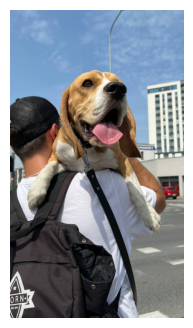

In [ ]:
sv.plot_image(image=image, size=(4,4))

In [ ]:
model = YOLO("yolov8x.pt")
result = model(image, verbose=True)[0]
image_detections = sv.Detections.from_ultralytics(result)


0: 640x384 1 person, 1 car, 1 dog, 1 backpack, 63.7ms
Speed: 1.8ms preprocess, 63.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 384)


In [ ]:
# image_detections

In [ ]:
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

In [ ]:
labels = [
    f"{model.model.names[class_id]} {confidence:.2f}"
    for class_id, confidence in zip(detections.class_id, detections.confidence)
]

print(labels)

['person 0.93', 'dog 0.92', 'backpack 0.88', 'car 0.78']


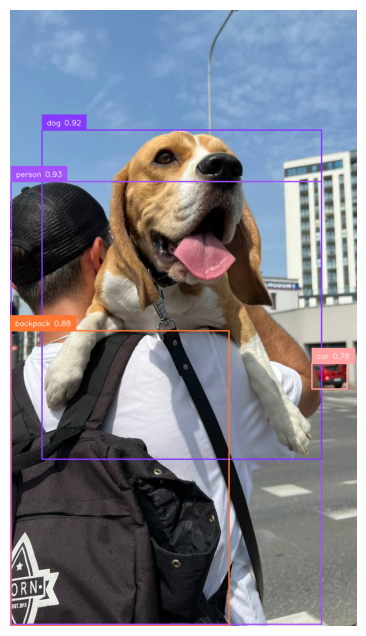

In [ ]:
annotated_image = image.copy()
annotated_image = box_annotator.annotate(
    annotated_image,
    detections=image_detections
)
annotated_image = label_annotator.annotate(
    annotated_image,
    detections=image_detections,
    labels=labels
)

# Display
sv.plot_image(image=annotated_image, size=(8,8))

### 1.4.2 MaskAnnotator

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8x-seg.pt")
result = model(image, verbose=False)[0]
image_detections = sv.Detections.from_ultralytics(result)

100%|██████████| 137M/137M [00:01<00:00, 126MB/s]


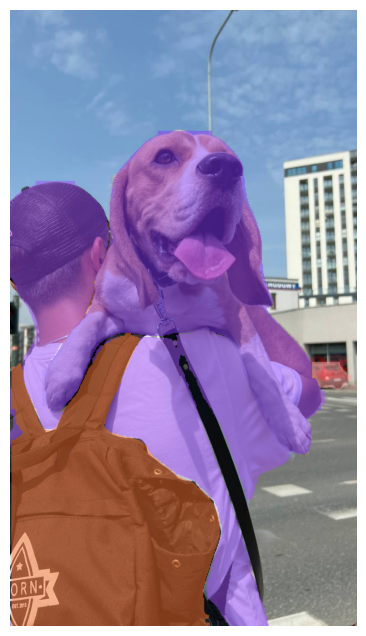

In [ ]:
mask_annotator = sv.MaskAnnotator()

annotated_image = image.copy()
annotated_image = mask_annotator.annotate(
    annotated_image,
    detections=image_detections
)

sv.plot_image(image=annotated_image, size=(8, 8))

In [ ]:
len(image_detections)

4